In [11]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt

load_dotenv()

engine = create_engine(os.environ['DATABASE'])

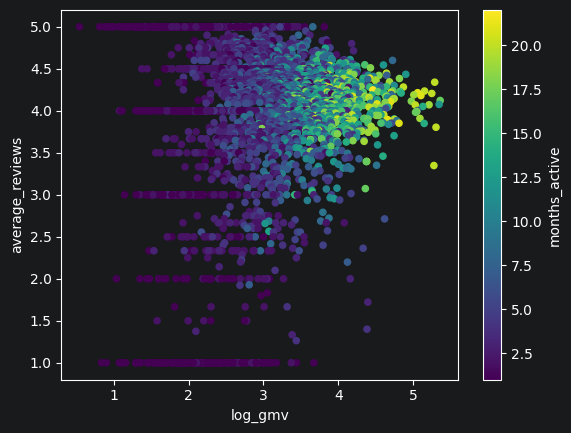

In [12]:
Query = """SELECT raw.order_items.seller_id AS seller, COUNT(DISTINCT date_trunc('month', raw.orders.order_purchase_timestamp::timestamp)) AS months_active, AVG(raw.reviews.review_score) AS average_reviews, SUM(raw.order_items.price) AS gmv
FROM raw.order_items
INNER JOIN raw.orders ON raw.order_items.order_id = raw.orders.order_id
LEFT JOIN raw.reviews ON raw.orders.order_id = raw.reviews.order_id
GROUP BY seller
ORDER BY average_reviews DESC;"""


combined = pd.read_sql(Query, engine)
combined['log_gmv'] = np.log10(combined['gmv'])
combined.plot(kind='scatter', x='Log of GMV', y='Average Reviews', c='Months Active', cmap='viridis')
plt.show()